In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import re
from collections import defaultdict

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 16  # 增大全局字体大小
plt.rcParams['axes.titlesize'] = 20  # 增大子图标题字体大小
plt.rcParams['axes.labelsize'] = 18  # 增大坐标轴标签字体大小
plt.rcParams['xtick.labelsize'] = 16  # 增大x轴刻度标签字体大小
plt.rcParams['ytick.labelsize'] = 16  # 增大y轴刻度标签字体大小
plt.rcParams['legend.fontsize'] = 16  # 增大图例字体大小

BASE_DIR = "hessian_analysis/hessian_epochs"
PDE_SETTINGS = [
    "poisson_scale_k1.0_2.5_val1024_1M",
    "poisson_scale_k100.0_200.0_val1024_1M",
    "poisson_scale_k1.0_2.5_val1024_16M",
    "poisson_scale_k100.0_200.0_val1024_16M",
]

# eps和subsample的对应关系
EPS_SUBSAMPLE_MAPPING = {
    50: "subsample1",
    100: "subsample4",
    200: "subsample16",
    500: "subsample64",
}

SEEDS = [2021, 2022, 2023] 

def parse_hessian_file(file_path):
    """解析hessian结果文件，提取largest_eigenvalue"""
    try:
        with open(file_path, 'r') as f:
            content = f.read()
            
        # 提取largest_eigenvalue
        match = re.search(r'largest_eigenvalue:\s*([\d.]+)', content)
        if match:
            return float(match.group(1))
        else:
            return None
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def collect_hessian_data():
    """收集所有hessian数据"""
    data = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
    
    for eps, subsample in EPS_SUBSAMPLE_MAPPING.items():
        step = eps // 50  # 计算epoch步长
        print(f"Processing eps{eps} -> {subsample} (step={step})")
        
        for pde_setting in PDE_SETTINGS:
            subsample_dir = f"{BASE_DIR}/expts_eps{eps}/{pde_setting}/hessian_analysis_pyhessian_eigenvalues_topN1/bsz128_lr0.001_{subsample}"
            
            if not os.path.exists(subsample_dir):
                print(f"  Directory not found: {subsample_dir}")
                continue
            
            # 扫描所有epoch和seed组合
            for item in os.listdir(subsample_dir):
                if item.startswith("seed") and "_ckpt_epoch" in item:
                    # 解析seed和epoch
                    parts = item.split("_")
                    seed = int(parts[0].replace("seed", ""))
                    epoch = int(parts[2].replace("epoch", ""))
                    
                    if seed in SEEDS:
                        hessian_file = os.path.join(subsample_dir, item, "hessian_pyhessian_eigenvalues_results.txt")
                        if os.path.exists(hessian_file):
                            largest_eigenvalue = parse_hessian_file(hessian_file)
                            if largest_eigenvalue is not None:
                                data[pde_setting][subsample][epoch][seed] = largest_eigenvalue
    
    return data

# 收集数据
print("开始收集hessian数据...")
hessian_data = collect_hessian_data()
print("数据收集完成！")

开始收集hessian数据...
Processing eps50 -> subsample1 (step=1)


Processing eps100 -> subsample4 (step=2)
Processing eps200 -> subsample16 (step=4)
Processing eps500 -> subsample64 (step=10)
数据收集完成！


In [14]:
def process_data_for_plotting(hessian_data):
    """处理数据用于绘图，计算每个(pde_setting, subsample, epoch)组合的均值和标准差"""
    plot_data = []
    
    for pde_setting in hessian_data:
        for subsample in hessian_data[pde_setting]:
            epochs = sorted(hessian_data[pde_setting][subsample].keys())
            
            for epoch in epochs:
                eigenvalues = list(hessian_data[pde_setting][subsample][epoch].values())
                if len(eigenvalues) > 0:
                    mean_val = np.mean(eigenvalues)
                    std_val = np.std(eigenvalues) if len(eigenvalues) > 1 else 0
                    n_seeds = len(eigenvalues)
                    
                    plot_data.append({
                        'pde_setting': pde_setting,
                        'subsample': subsample,
                        'epoch': epoch,
                        'mean_eigenvalue': mean_val,
                        'std_eigenvalue': std_val,
                        'n_seeds': n_seeds,
                        'eigenvalues': eigenvalues
                    })
    
    return pd.DataFrame(plot_data)

def print_data_summary(plot_df):
    """打印hessian数据摘要"""
    print(f"\n=== HESSIAN 数据摘要 ===")
    print(f"总计数据点: {len(plot_df)}")
    
    for pde_setting in PDE_SETTINGS:
        print(f"\n{pde_setting}:")
        pde_data = plot_df[plot_df['pde_setting'] == pde_setting]
        
        for subsample in sorted(pde_data['subsample'].unique(), 
                               key=lambda x: int(x.replace('subsample', ''))):
            subsample_data = pde_data[pde_data['subsample'] == subsample]
            n_epochs = len(subsample_data)
            epoch_range = f"{subsample_data['epoch'].min()}-{subsample_data['epoch'].max()}" if n_epochs > 0 else "N/A"
            avg_seeds = subsample_data['n_seeds'].mean() if n_epochs > 0 else 0
            
            print(f"  {subsample}: {n_epochs} epochs ({epoch_range}), avg {avg_seeds:.1f} seeds per epoch")

def create_hessian_plots(plot_df):
    """创建2x2四宫格布局的Hessian eigenvalue图表"""
    
    subsamples = sorted(plot_df['subsample'].unique(), 
                       key=lambda x: int(x.replace('subsample', '')))
    colors = plt.cm.tab10(np.linspace(0, 1, len(subsamples)))
    color_map = dict(zip(subsamples, colors))
    
    # 创建2x2的子图布局
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()  # 将2x2数组展平为1维数组，便于索引
    
    for idx, pde_setting in enumerate(PDE_SETTINGS):
        # 过滤当前PDE设置的数据
        pde_data = plot_df[plot_df['pde_setting'] == pde_setting]
        
        if len(pde_data) == 0:
            print(f"警告: 没有找到 {pde_setting} 的数据")
            continue
            
        ax = axes[idx]
        
        for subsample in subsamples:
            subsample_data = pde_data[pde_data['subsample'] == subsample]
            if len(subsample_data) == 0:
                continue
                
            # 按epoch排序
            subsample_data = subsample_data.sort_values('epoch')
            
            epochs = subsample_data['epoch'].values
            means = subsample_data['mean_eigenvalue'].values
            stds = subsample_data['std_eigenvalue'].values
            
            # 画主线
            subsample_num = int(subsample.replace('subsample', ''))
            label = f'Subsample {subsample_num}'
            ax.plot(epochs, means, color=color_map[subsample], 
                   linewidth=2, marker='o', markersize=3, label=label)
            
            # 画标准差区间
            ax.fill_between(epochs, means - stds, means + stds, 
                           color=color_map[subsample], alpha=0.2)
        
        # 设置图形属性（使用更大的字体以适合会议展示）
        ax.set_xlabel('Epoch', fontsize=18)
        ax.set_ylabel('Largest Eigenvalue', fontsize=18)
        
        # 简化标题以适应四宫格布局
        title_parts = pde_setting.split('_')
        if 'k1.0' in pde_setting and '1M' in pde_setting:
            short_title = 'k=1.0-2.5, 1M params'
        elif 'k100.0' in pde_setting and '1M' in pde_setting:
            short_title = 'k=100-200, 1M params'
        elif 'k1.0' in pde_setting and '16M' in pde_setting:
            short_title = 'k=1.0-2.5, 16M params'
        elif 'k100.0' in pde_setting and '16M' in pde_setting:
            short_title = 'k=100-200, 16M params'
        else:
            short_title = pde_setting.replace('poisson_scale_', '').replace('_val1024_', ', ')
        
        ax.set_title(short_title, fontsize=20, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=16, loc='best')  # 增大图例字体并优化位置
    
    # 设置整体标题
    fig.suptitle('Hessian Largest Eigenvalue by Epochs', fontsize=24, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.94)  # 为整体标题留出空间
    plt.show()
    
    return fig

def analyze_hessian_trends(plot_df):
    """分析Hessian eigenvalue趋势"""
    print("\n=== HESSIAN特征值趋势分析 ===")
    
    for pde_setting in PDE_SETTINGS:
        print(f"\n{pde_setting.replace('_', ' ')}:")
        
        pde_data = plot_df[plot_df['pde_setting'] == pde_setting]
        
        for subsample in sorted(pde_data['subsample'].unique(), 
                               key=lambda x: int(x.replace('subsample', ''))):
            subsample_data = pde_data[pde_data['subsample'] == subsample].sort_values('epoch')
            
            if len(subsample_data) < 2:
                continue
                
            # 最终特征值
            final_eigenvalue = subsample_data.iloc[-1]['mean_eigenvalue']
            initial_eigenvalue = subsample_data.iloc[0]['mean_eigenvalue']
            
            eps = [k for k, v in EPS_SUBSAMPLE_MAPPING.items() if v == subsample][0]
            
            # 变化百分比
            change_pct = (final_eigenvalue / initial_eigenvalue - 1) * 100 if initial_eigenvalue != 0 else 0
            
            print(f"  {subsample} (eps={eps}): {initial_eigenvalue:.4f} → {final_eigenvalue:.4f} ({change_pct:+.1f}%)")


处理Hessian数据...

=== HESSIAN 数据摘要 ===
总计数据点: 480

poisson_scale_k1.0_2.5_val1024_1M:
  subsample1: 50 epochs (0-49), avg 3.0 seeds per epoch
  subsample4: 50 epochs (0-98), avg 3.0 seeds per epoch
  subsample16: 50 epochs (0-196), avg 3.0 seeds per epoch
  subsample64: 50 epochs (0-490), avg 3.0 seeds per epoch

poisson_scale_k100.0_200.0_val1024_1M:
  subsample1: 50 epochs (0-49), avg 3.0 seeds per epoch
  subsample4: 50 epochs (0-98), avg 3.0 seeds per epoch
  subsample16: 50 epochs (0-196), avg 3.0 seeds per epoch
  subsample64: 50 epochs (0-490), avg 3.0 seeds per epoch

poisson_scale_k1.0_2.5_val1024_16M:
  subsample1: 10 epochs (0-45), avg 3.0 seeds per epoch
  subsample4: 10 epochs (0-90), avg 3.0 seeds per epoch
  subsample16: 10 epochs (0-180), avg 3.0 seeds per epoch
  subsample64: 10 epochs (0-450), avg 3.0 seeds per epoch

poisson_scale_k100.0_200.0_val1024_16M:
  subsample1: 10 epochs (0-45), avg 3.0 seeds per epoch
  subsample4: 10 epochs (0-90), avg 3.0 seeds per epoch
  

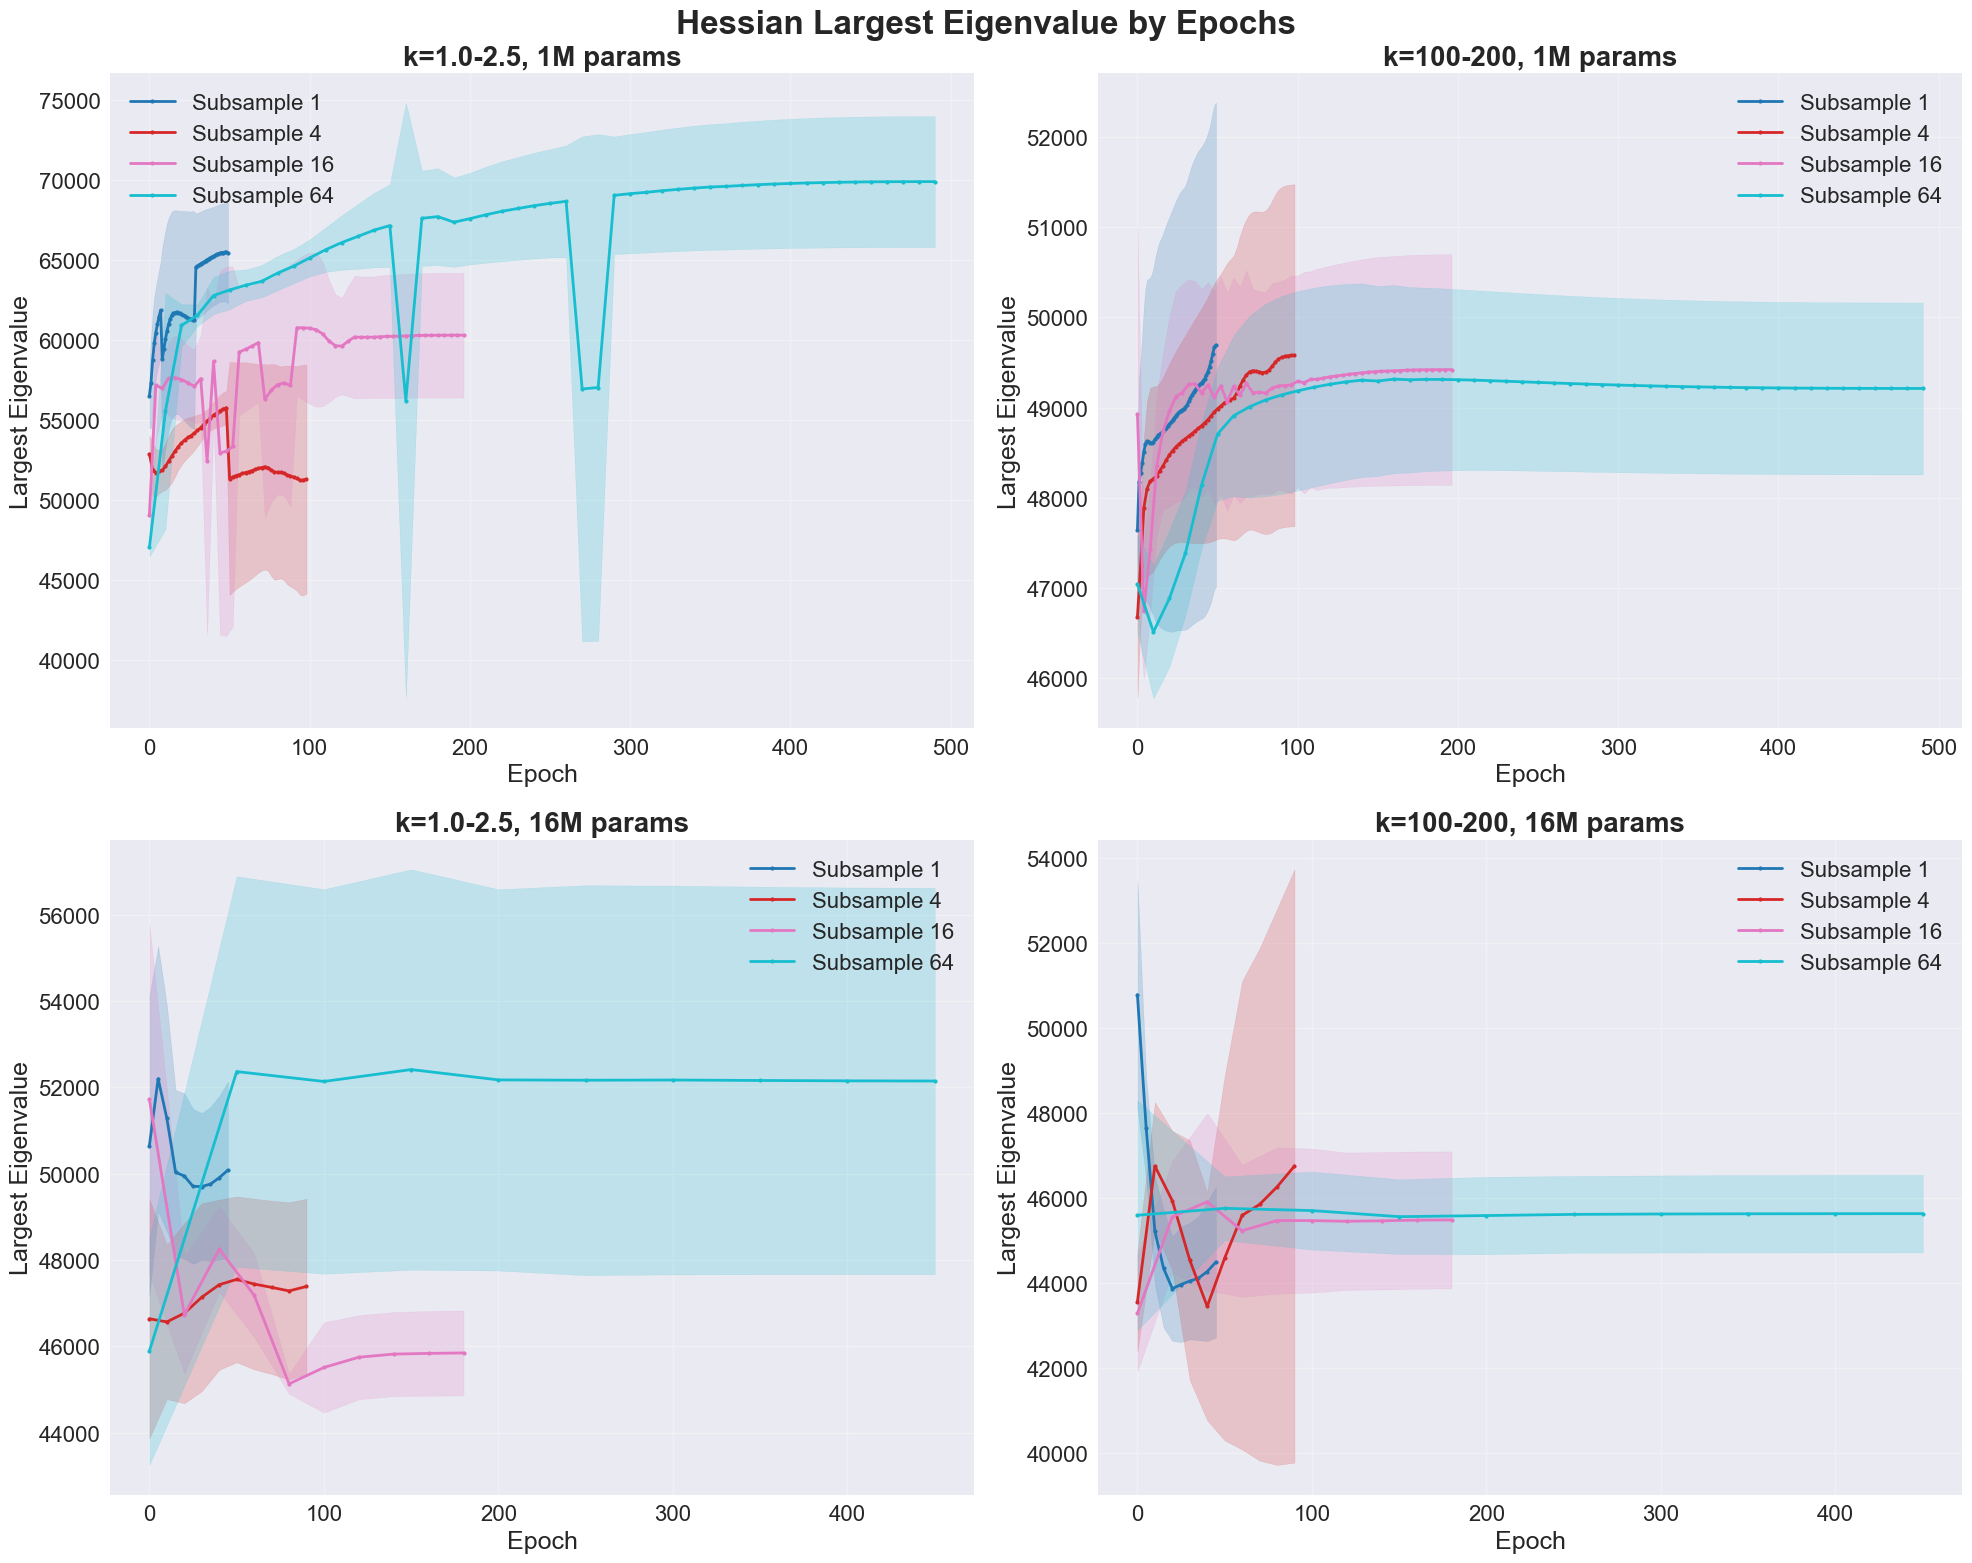


分析Hessian特征值趋势...

=== HESSIAN特征值趋势分析 ===

poisson scale k1.0 2.5 val1024 1M:
  subsample1 (eps=50): 56526.6081 → 65440.7396 (+15.8%)
  subsample4 (eps=100): 52875.3346 → 51309.7318 (-3.0%)
  subsample16 (eps=200): 49094.0169 → 60305.8945 (+22.8%)
  subsample64 (eps=500): 47041.1146 → 69905.2500 (+48.6%)

poisson scale k100.0 200.0 val1024 1M:
  subsample1 (eps=50): 47644.0117 → 49693.6602 (+4.3%)
  subsample4 (eps=100): 46681.6133 → 49580.8763 (+6.2%)
  subsample16 (eps=200): 48928.0104 → 49420.8893 (+1.0%)
  subsample64 (eps=500): 47044.4609 → 49212.4297 (+4.6%)

poisson scale k1.0 2.5 val1024 16M:
  subsample1 (eps=50): 50654.9922 → 50085.7969 (-1.1%)
  subsample4 (eps=100): 46641.3815 → 47390.5521 (+1.6%)
  subsample16 (eps=200): 51723.6315 → 45850.4831 (-11.4%)
  subsample64 (eps=500): 45895.5312 → 52149.1823 (+13.6%)

poisson scale k100.0 200.0 val1024 16M:
  subsample1 (eps=50): 50774.7630 → 44495.0352 (-12.4%)
  subsample4 (eps=100): 43559.2930 → 46750.0339 (+7.3%)
  subsample

In [15]:
# =====================================
# 精简版Hessian可视化执行
# =====================================

# 处理数据并生成精简版可视化
print("处理Hessian数据...")
plot_df = process_data_for_plotting(hessian_data)

print_data_summary(plot_df)

print("\n=== 精简版Hessian可视化开始 ===")
print("\n创建Hessian特征值图表 (2x2四宫格布局)...")
hessian_fig = create_hessian_plots(plot_df)

print("\n分析Hessian特征值趋势...")
analyze_hessian_trends(plot_df)

print("\n=== 精简版Hessian可视化完成！===")
print("\n总共生成图表数: 1个四宫格图表包含4个子图")
print("图表布局: 2x2四宫格，每个子图显示一个PDE设置的线性尺度Hessian特征值变化")
print("PDE设置:")
for pde in PDE_SETTINGS:
    print(f"  - {pde}")
print("\n每个子图显示不同subsample设置下的Hessian最大特征值随epoch的变化")
